In [10]:
from sklearn.datasets import load_breast_cancer
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

In [11]:
data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    data.data, data.target, test_size=0.2, random_state=42, stratify=data.target)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

In [12]:
svm = SVC(kernel='linear',C =1,random_state=42)
svm.fit(X_train_s,y_train)
print("Linear SVM accuracy:", round(accuracy_score(y_test, svm.predict(X_test_s)), 4))
print("Number of support vectors:", svm.n_support_, "out of", X_train_s.shape[0], "training points")

Linear SVM accuracy: 0.9737
Number of support vectors: [15 17] out of 455 training points


**RBF ( NON LINEAR KERNEL)**

In [13]:
svm = SVC(kernel='rbf',C =1,random_state=42)
svm.fit(X_train_s,y_train)
print("RBF SVM accuracy:", round(accuracy_score(y_test, svm.predict(X_test_s)), 4))
print("Number of support vectors:", svm.n_support_, "out of", X_train_s.shape[0], "training points")

RBF SVM accuracy: 0.9825
Number of support vectors: [51 46] out of 455 training points


Linear kernel accuracy: 0.5933
RBF    kernel accuracy: 1.0


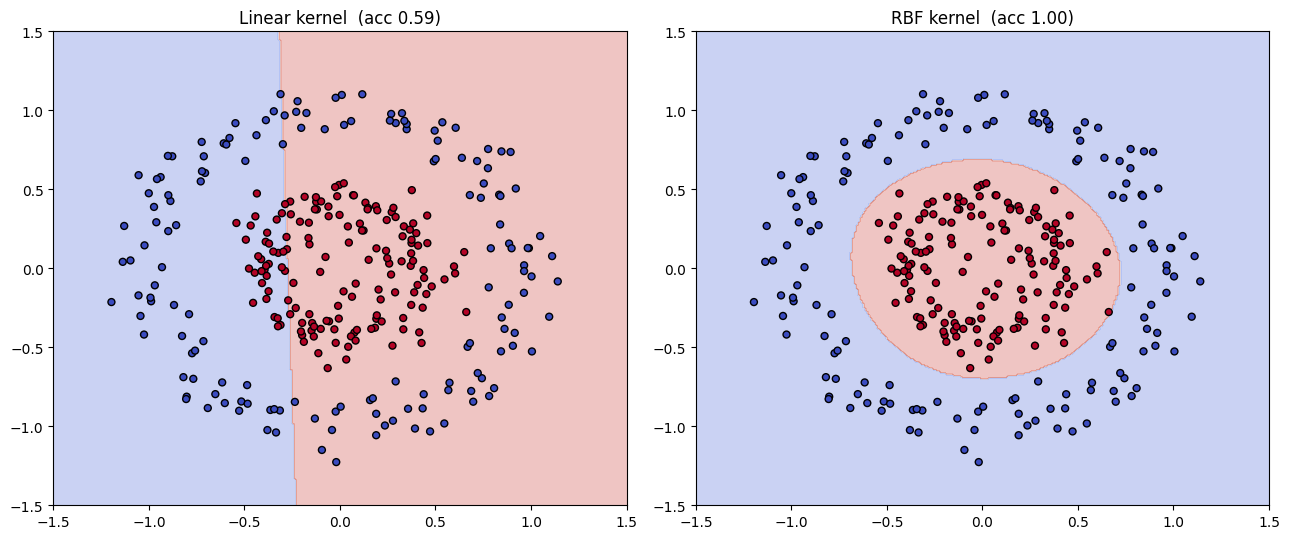

In [14]:
import numpy as np, matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_circles
from sklearn.metrics import accuracy_score

# Data: one class is a ring AROUND the other. No straight line can separate these.
X, y = make_circles(n_samples=300, factor=0.4, noise=0.1, random_state=42)

# Fit two SVMs: linear vs RBF kernel
lin = SVC(kernel='linear', C=1).fit(X, y)
rbf = SVC(kernel='rbf', C=1, gamma='scale').fit(X, y)
print("Linear kernel accuracy:", round(accuracy_score(y, lin.predict(X)), 4))
print("RBF    kernel accuracy:", round(accuracy_score(y, rbf.predict(X)), 4))

# Plot both decision boundaries side by side
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
xx, yy = np.meshgrid(np.linspace(-1.5, 1.5, 300), np.linspace(-1.5, 1.5, 300))
for ax, model, name in [(axes[0], lin, 'Linear kernel'), (axes[1], rbf, 'RBF kernel')]:
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', s=25, edgecolor='k')
    ax.set_title(f'{name}  (acc {accuracy_score(y, model.predict(X)):.2f})')
plt.tight_layout(); plt.savefig('kernels.png', dpi=110); plt.show()

**How to tune gamma and C**

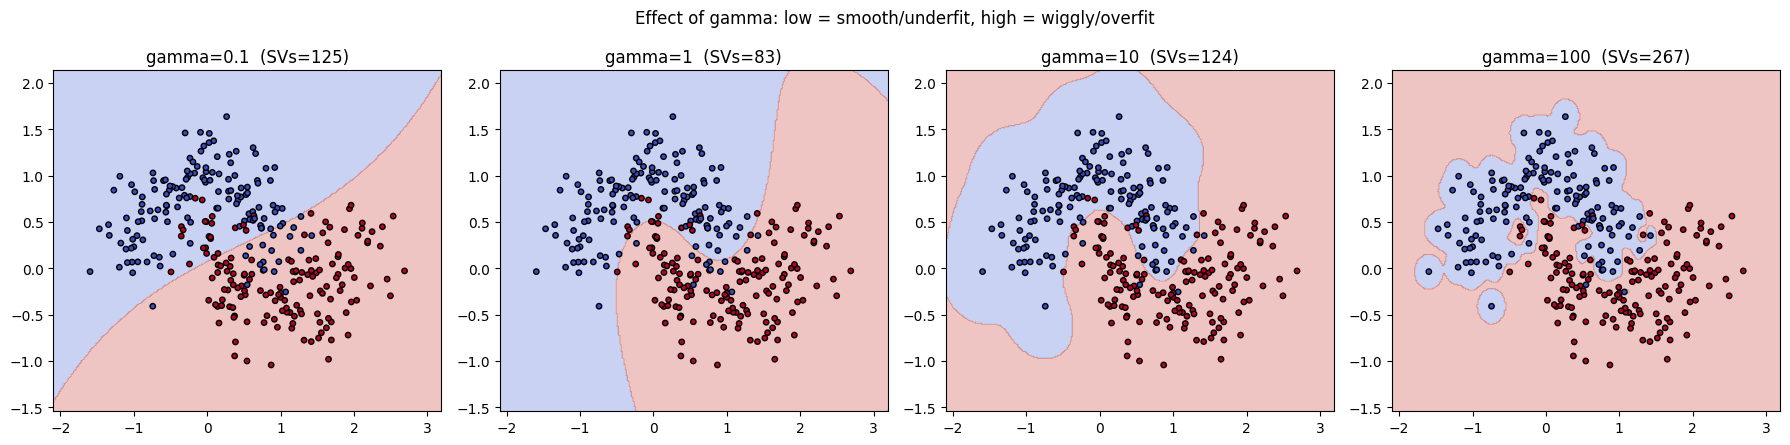

In [15]:
import numpy as np, matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_moons

# Two interleaving half-moons with noise — needs a curved boundary
X, y = make_moons(n_samples=300, noise=0.25, random_state=42)
xx, yy = np.meshgrid(np.linspace(X[:,0].min()-0.5, X[:,0].max()+0.5, 300),
                     np.linspace(X[:,1].min()-0.5, X[:,1].max()+0.5, 300))

# Vary gamma across a wide range, fixed C=1
gammas = [0.1, 1, 10, 100]
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for ax, g in zip(axes, gammas):
    m = SVC(kernel='rbf', C=1, gamma=g).fit(X, y)
    Z = m.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', s=15, edgecolor='k')
    ax.set_title(f'gamma={g}  (SVs={m.support_.shape[0]})')
plt.suptitle('Effect of gamma: low = smooth/underfit, high = wiggly/overfit')
plt.tight_layout(); plt.savefig('gamma.png', dpi=110); plt.show()